Imports and Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
import random

In [2]:
path = kagglehub.dataset_download("yasserh/uber-fares-dataset")

In [3]:
df = pd.read_csv(path + '/uber.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df[df.duplicated()]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


In [8]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,1.601386e+07,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382534e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774524e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155535e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [9]:
df = df[
    (df['fare_amount'] > 0) & (df['fare_amount'] < 200) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6) &
    (df['pickup_longitude'].between(-74.5, -72.9)) &
    (df['pickup_latitude'].between(40.5, 41.8)) &
    (df['dropoff_longitude'].between(-74.5, -72.9)) &
    (df['dropoff_latitude'].between(40.5, 41.8))
]

In [10]:
df.head(5)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [11]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195066 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Unnamed: 0         195066 non-null  int64              
 1   key                195066 non-null  object             
 2   fare_amount        195066 non-null  float64            
 3   pickup_datetime    195066 non-null  datetime64[ns, UTC]
 4   pickup_longitude   195066 non-null  float64            
 5   pickup_latitude    195066 non-null  float64            
 6   dropoff_longitude  195066 non-null  float64            
 7   dropoff_latitude   195066 non-null  float64            
 8   passenger_count    195066 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(2), object(1)
memory usage: 14.9+ MB


In [12]:
df['Year'] = df.pickup_datetime.dt.year
df['Month'] = df.pickup_datetime.dt.month
df['Hour'] = df.pickup_datetime.dt.hour

df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195066 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Unnamed: 0         195066 non-null  int64              
 1   key                195066 non-null  object             
 2   fare_amount        195066 non-null  float64            
 3   pickup_datetime    195066 non-null  datetime64[ns, UTC]
 4   pickup_longitude   195066 non-null  float64            
 5   pickup_latitude    195066 non-null  float64            
 6   dropoff_longitude  195066 non-null  float64            
 7   dropoff_latitude   195066 non-null  float64            
 8   passenger_count    195066 non-null  int64              
 9   Year               195066 non-null  int32              
 10  Month              195066 non-null  int32              
 11  Hour               195066 non-null  int32              
 12  hour_sin           195066 non-null 

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    
    # distance between latitudes
    # and longitudes
    dLat = (lat2 - lat1) * np.pi / 180.0
    dLon = (lon2 - lon1) * np.pi / 180.0

    # convert to radians
    lat1 = (lat1) * np.pi / 180.0
    lat2 = (lat2) * np.pi / 180.0

    # apply formulae
    a = (pow(np.sin(dLat / 2), 2) + 
         pow(np.sin(dLon / 2), 2) * 
             np.cos(lat1) * np.cos(lat2));
    rad = 6371
    c = 2 * np.asin(np.sqrt(a))
    return rad * c

In [14]:
df['Distance'] = haversine(df.pickup_latitude, df.pickup_longitude, df.dropoff_latitude, df.dropoff_longitude)

In [15]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'Year', 'Month', 'Hour',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Distance'],
      dtype='object')

In [16]:
A = df.drop({'Unnamed: 0','pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude','key', 'Hour', 'Month' },axis=1)
A.head(5)

,fare_amount,passenger_count,Year,hour_sin,hour_cos,month_sin,month_cos,Distance
0,7.5,1,2015,-0.965926,0.258819,5.000000e-01,-0.866025,1.683323
1,7.7,1,2009,-0.866025,0.500000,-5.000000e-01,-0.866025,2.457590
2,12.9,1,2009,-0.707107,0.707107,-8.660254e-01,-0.500000,5.036377
3,5.3,3,2009,0.866025,-0.500000,1.224647e-16,-1.000000,1.661683
4,16.0,5,2014,-0.965926,-0.258819,-8.660254e-01,-0.500000,4.475450


In [17]:
A.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195066 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fare_amount      195066 non-null  float64
 1   passenger_count  195066 non-null  int64  
 2   Year             195066 non-null  int32  
 3   hour_sin         195066 non-null  float64
 4   hour_cos         195066 non-null  float64
 5   month_sin        195066 non-null  float64
 6   month_cos        195066 non-null  float64
 7   Distance         195066 non-null  float64
dtypes: float64(6), int32(1), int64(1)
memory usage: 12.7 MB


In [18]:
A.describe()

,fare_amount,passenger_count,Year,hour_sin,hour_cos,month_sin,month_cos,Distance
count,195066.000000,195066.000000,195066.000000,195066.000000,195066.000000,1.950660e+05,1.950660e+05,195066.000000
mean,11.343493,1.689746,2011.740565,-0.194671,-0.068875,5.301090e-02,-1.471364e-02,3.329603
std,9.694907,1.305591,1.862271,0.668591,0.714388,7.052014e-01,7.068730e-01,3.750999
min,0.010000,1.000000,2009.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000e+00,0.000000
25%,6.000000,1.000000,2010.000000,-0.866025,-0.707107,-5.000000e-01,-8.660254e-01,1.256025
50%,8.500000,1.000000,2012.000000,-0.258819,-0.258819,1.224647e-16,6.123234e-17,2.157154
75%,12.500000,2.000000,2013.000000,0.500000,0.707107,8.660254e-01,5.000000e-01,3.908649
max,196.000000,6.000000,2015.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,115.073410


In [19]:
X = A.drop('fare_amount', axis=1)
y = A.fare_amount

Regression Analysis

In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0
)

In [22]:
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)
y_mean = np.mean(y_train)
y_std = np.std(y_train)

X_train = preprocessor.fit_transform(X_train)
y_train = (y_train-y_mean)/(y_std)

X_test = preprocessor.transform(X_test)
y_test = (y_test-y_mean)/(y_std)

1. Model 1: Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score

In [24]:
np.random.seed(0)

In [25]:
LinReg = LinearRegression()
LinReg.fit(X_train, y_train)
predLinReg = LinReg.predict(X_test)
r2LinReg = r2_score(y_test, predLinReg)
print(f"R² Score: {r2LinReg:.4f}")

R² Score: 0.6813


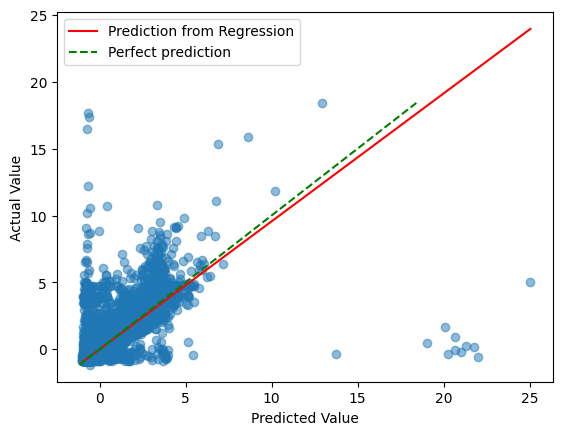

In [26]:
plt.scatter(predLinReg, y_test, alpha=0.5)

# Best fit line
m, b = np.polyfit(predLinReg, y_test, 1)
x_line = np.linspace(min(predLinReg), max(predLinReg), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Prediction from Regression')

# Perfect prediction line (optional but useful)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='green', linestyle='--', label='Perfect prediction')

plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.legend()
plt.show()

2. Model 2: LASSO

In [27]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lassor2 = r2_score(y_test, lasso_pred)
print(f"R² Score: {lassor2:.4f}")

R² Score: 0.6652


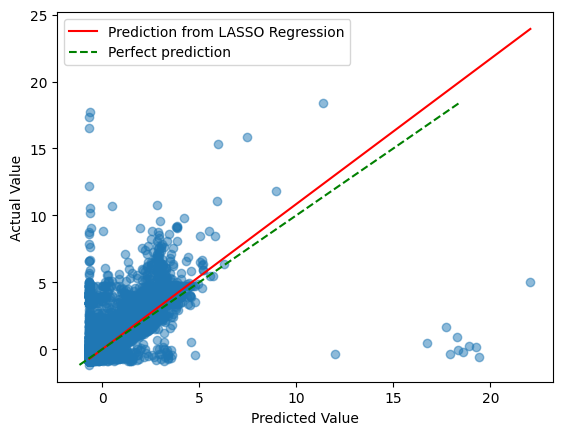

In [28]:
plt.scatter(lasso_pred, y_test, alpha=0.5)

# Best fit line
m, b = np.polyfit(lasso_pred, y_test, 1)
x_line = np.linspace(min(lasso_pred), max(lasso_pred), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Prediction from LASSO Regression')

# Perfect prediction line (optional but useful)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='green', linestyle='--', label='Perfect prediction')

plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.legend()
plt.show()

3. Model 3: Ridge Regression

In [29]:
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridger2 = r2_score(y_test, ridge_pred)
print(f"R² Score: {ridger2:.4f}")

R² Score: 0.6813


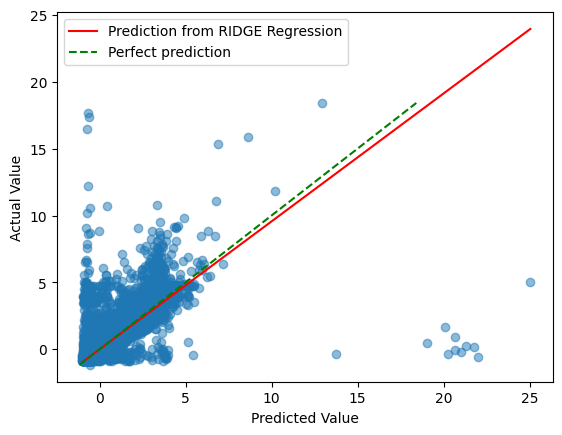

In [30]:
plt.scatter(ridge_pred, y_test, alpha=0.5)

# Best fit line
m, b = np.polyfit(ridge_pred, y_test, 1)
x_line = np.linspace(min(ridge_pred), max(ridge_pred), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Prediction from RIDGE Regression')

# Perfect prediction line (optional but useful)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='green', linestyle='--', label='Perfect prediction')

plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.legend()
plt.show()

4. Model 4: xgboost

In [31]:
from xgboost import XGBRegressor

In [32]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=0)
xgb.fit(X_train, y_train)
pred_xg = xgb.predict(X_test)
r2xg = r2_score(y_test, pred_xg)
print(f"R² Score: {r2xg:.4f}")

R² Score: 0.7831


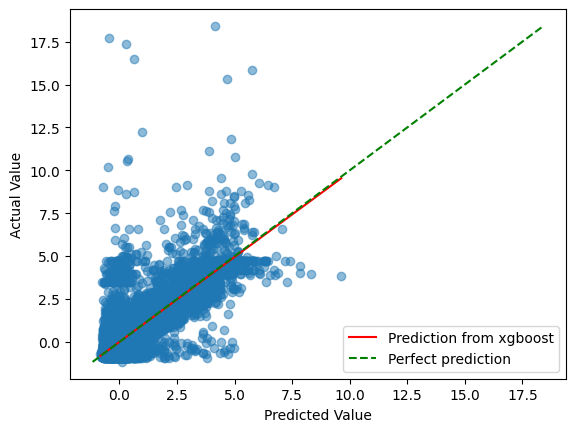

In [33]:
plt.scatter(pred_xg, y_test, alpha=0.5)

# Best fit line
m, b = np.polyfit(pred_xg, y_test, 1)
x_line = np.linspace(min(pred_xg), max(pred_xg), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Prediction from xgboost')

# Perfect prediction line (optional but useful)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='green', linestyle='--', label='Perfect prediction')

plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.legend()
plt.show()

5. Model 5: Neural Net

In [34]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
tf.random.set_seed(0)

In [35]:
def build_model():
    model = tf.keras.Sequential([
        Dense(32, activation=tf.nn.relu, input_shape=[len(X_train[0])]),
        Dense(16, activation=tf.nn.relu),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss='mse',
                  metrics=['mae', 'mse'])
    return model

In [37]:
model = build_model()
        
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50)
history = model.fit(X_train, y_train, epochs=1000, verbose=0, validation_split = 0.1,
                    callbacks=[early_stop])

hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch


predictions = model.predict(X_test)

1829/1829 ━━━━━━━━━━━━━━━━━━━━ 0s 186us/step


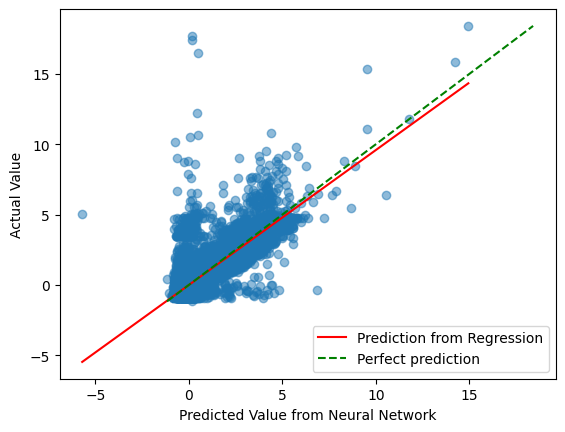

In [38]:
predictions = predictions.flatten()
plt.scatter(predictions, y_test, alpha=0.5)

# Best fit line
m, b = np.polyfit(predictions, y_test, 1)
x_line = np.linspace(min(predictions), max(predictions), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Prediction from Regression')

# Perfect prediction line (optional but useful)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='green', linestyle='--', label='Perfect prediction')

plt.xlabel('Predicted Value from Neural Network')
plt.ylabel('Actual Value')
plt.legend()
plt.show()

In [39]:
r2 = r2_score(y_test, predictions)
print(f"R² Score: {r2:.4f}")

R² Score: 0.7914


In [42]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'RIDGE',
        'LASSO',
        'XGBoost Regression',
        'Neural Net'
    ],
    'R2 Score': [
        r2_score(y_test, predLinReg),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, pred_xg),
        r2_score(y_test, predictions)
    ]
}).sort_values('R2 Score', ascending=False)

print(results.to_string(index=False))

             Model  R2 Score
        Neural Net  0.791399
XGBoost Regression  0.783068
             RIDGE  0.681273
 Linear Regression  0.681272
             LASSO  0.665242
